Import Libraries

In [156]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ML Models
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Load Dataset

In [157]:
df = pd.read_csv("../data/social_media_engagement_dataset.csv")

df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


Data Understanding

In [158]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   str    
 1   Timestamp        5000 non-null   str    
 2   Platform         5000 non-null   str    
 3   Content_Type     5000 non-null   str    
 4   Category         5000 non-null   str    
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   str    
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   str    
 17  Influencer_Tier  5000 non

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7536.838400,339.898800,835.233400,110968.397000,753.150600,249959.204000,11.960148,11.562600,14.755800,754.508400
std,10169.129568,399.813585,1013.769853,181287.350216,932.653475,144592.908235,71.462053,6.946577,8.666117,576.334039
min,18.000000,1.000000,2.000000,527.000000,5.000000,543.000000,0.050000,0.000000,0.000000,15.000000
25%,1707.750000,96.000000,177.000000,18506.750000,200.000000,124560.250000,1.030000,5.000000,7.000000,280.000000
50%,4073.500000,212.000000,427.500000,40663.500000,424.000000,248930.500000,2.300000,12.000000,15.000000,549.000000
75%,7783.000000,377.000000,1111.500000,84226.750000,805.000000,374697.500000,6.245000,18.000000,22.000000,1226.250000
max,49949.000000,1999.000000,4997.000000,999256.000000,4985.000000,499815.000000,3510.460000,23.000000,29.000000,1999.000000


Null check

In [159]:
df.isnull().sum()

Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64

In [160]:
print('Dataset Shape before duplicates removal:', df.shape)

# Remove duplicates
df = df.drop_duplicates()

print("Dataset Shape after duplicate removal:", df.shape)

Dataset Shape before duplicates removal: (5000, 20)
Dataset Shape after duplicate removal: (5000, 20)


## Feature Engineering

New features are created to enhance analysis:

- **Total Interactions**: Sum of likes, comments, shares, and saves.
- **Verified Engagement Rate**: Calculated using the formula:
  (Likes + Comments + Shares) / Views * 100
- **Timestamp Conversion**: Converted to datetime format for time-based analysis.
- **Posting Hour and Day**: Extracted from timestamp.

These features help in deriving meaningful insights from the data.

In [161]:
# Total Interactions
df["Total_Interactions"] = df["Likes"] + df["Comments"] + df["Shares"] + df["Saves"]

# Verified Engagement Rate
df["Verified_Engagement_Rate"] = ((df["Likes"] + df["Comments"] + df["Shares"]) / df["Views"]) * 100

# Convert Timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Extract Time Features
df["Posting_Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day_name()

## Peak Time Group

Posting hours are categorized into time intervals:

- Morning (5 AM – 12 PM)
- Afternoon (12 PM – 5 PM)
- Evening (5 PM – 9 PM)
- Night (9 PM – 5 AM)

This helps in analyzing engagement based on time of posting.

In [162]:
def get_time_group(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Peak_Time"] = df["Posting_Hour"].apply(get_time_group)

## Encoding Categorical Variables (ML + Visualization Safe)

In this step:

- Original categorical values are preserved in separate *_Label columns for visualization (Tableau).
- Encoded numerical values are created for Machine Learning models.

This ensures:
- Machine Learning models work correctly with numeric data.
- Dashboards remain readable with actual category names instead of numbers.

In [163]:
# Encoding categorical variables while preserving labels

le_dict = {}

categorical_cols = ["Platform", "Content_Type", "Sentiment", "Influencer_Tier", "Day_of_Week"]

for col in categorical_cols:
    le = LabelEncoder()
    
    # Preserve original values for Tableau
    df[col + "_Label"] = df[col]
    
    # Encode for ML
    df[col] = le.fit_transform(df[col])
    
    # Store mapping (for reference)
    le_dict[col] = dict(zip(le.classes_, le.transform(le.classes_)))

In [174]:
# Display encoding mappings (for understanding and viva)

for col, mapping in le_dict.items():
    print(f"\n{col} Encoding:")
    for key, value in mapping.items():
        print(f"{key} -> {value}")


Platform Encoding:
Facebook -> 0
Instagram -> 1
LinkedIn -> 2
TikTok -> 3
Twitter -> 4
YouTube -> 5

Content_Type Encoding:
Article -> 0
Carousel -> 1
Community Post -> 2
Document -> 3
Duet -> 4
Live -> 5
Photo -> 6
Poll -> 7
Post -> 8
Reel -> 9
Retweet -> 10
Short -> 11
Stitch -> 12
Story -> 13
Thread -> 14
Tweet -> 15
Video -> 16

Sentiment Encoding:
Negative -> 0
Neutral -> 1
Positive -> 2

Influencer_Tier Encoding:
Macro -> 0
Micro -> 1
Mid-tier -> 2
Nano -> 3

Day_of_Week Encoding:
Friday -> 0
Monday -> 1
Saturday -> 2
Sunday -> 3
Thursday -> 4
Tuesday -> 5
Wednesday -> 6


## Feature Scaling(Normalization)

Feature scaling is applied using StandardScaler to normalize numerical variables such as likes, comments, shares, views, and engagement rate.

This ensures that all features contribute equally to the clustering algorithm and prevents bias due to different scales.

In [175]:
cluster_features = ["Likes", "Comments", "Shares", "Views", "Verified_Engagement_Rate"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[cluster_features])

## Clustering using K-Means

K-Means clustering is used to group posts into different engagement categories.

- The dataset is divided into 3 clusters:
  - High Engagement
  - Moderate Engagement
  - Low Engagement

Clustering helps identify patterns in audience interaction.

In [176]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [177]:
cluster_map = {
    0: "High Engagement",
    1: "Moderate Engagement",
    2: "Low Engagement"
}
df["Cluster_Label"] = df["Cluster"].map(cluster_map)

Visualizing Clusters

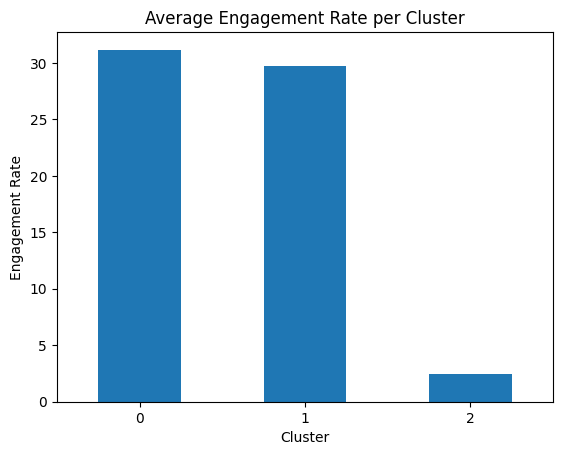

In [178]:
df.groupby("Cluster")["Verified_Engagement_Rate"].mean().plot(kind="bar")
plt.title("Average Engagement Rate per Cluster")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=0)
plt.show()

## Cluster Analysis

The mean values of engagement-related features are calculated for each cluster.

This provides insights into:
- Which cluster has the highest engagement
- Differences in likes, comments, and shares across clusters

This step helps interpret the clustering results in business terms.

In [179]:
df.groupby("Cluster")[["Verified_Engagement_Rate", "Likes", "Comments", "Shares"]].mean()

,Verified_Engagement_Rate,Likes,Comments,Shares
Cluster,,,,
0,31.167100,3838.949697,196.508595,508.508595
1,29.749144,29156.261011,1113.753670,2777.293638
2,2.491501,10729.742459,555.394432,1071.986079


Platform vs Engagement Rate

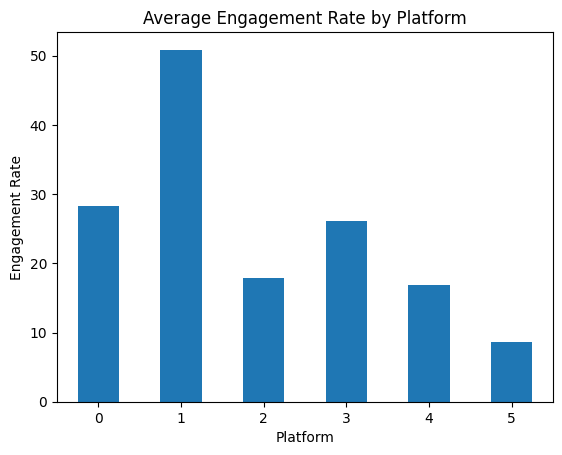

In [180]:
df.groupby("Platform")["Verified_Engagement_Rate"].mean().plot(kind="bar")
plt.title("Average Engagement Rate by Platform")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=0)
plt.show()

Content Type vs Engagement

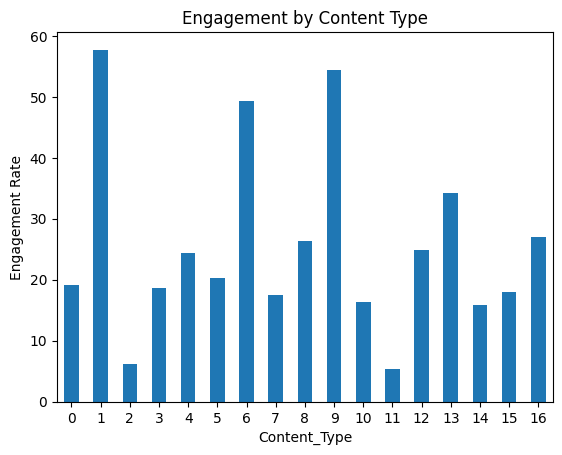

In [181]:
df.groupby("Content_Type")["Verified_Engagement_Rate"].mean().plot(kind="bar")
plt.title("Engagement by Content Type")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=0)
plt.show()

Day of Week Analysis

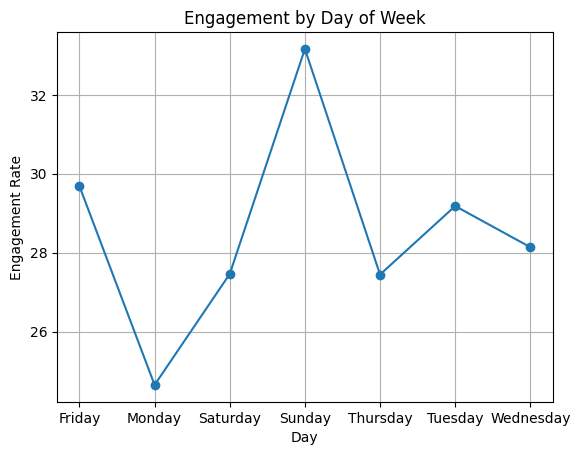

In [182]:
df.groupby("Day")["Verified_Engagement_Rate"].mean().plot(kind="line", marker="o")
plt.title("Engagement by Day of Week")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=0)
plt.grid()
plt.show()

Sentiment vs Engagement

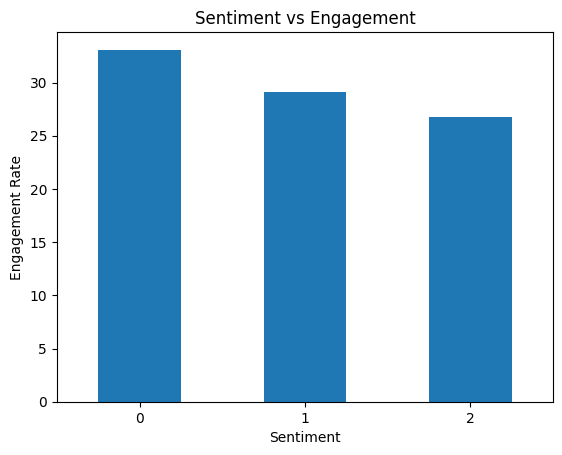

In [183]:
df.groupby("Sentiment")["Verified_Engagement_Rate"].mean().plot(kind="bar")
plt.title("Sentiment vs Engagement")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=0)
plt.show()

## Target Variable Creation

A new binary target variable is created:

- High Engagement (1)
- Low Engagement (0)

This is based on whether the engagement rate is above the average.

This variable is used for classification.

In [184]:
threshold = df["Verified_Engagement_Rate"].mean()
df["High_Engagement"] = (df["Verified_Engagement_Rate"] > threshold).astype(int)

## Classification using Logistic Regression

Logistic Regression is used to predict whether a post will have high engagement.

Input features include platform, content type, sentiment, posting hour, and follower count.

The model is trained on a portion of the data and tested on the remaining data.

In [185]:
X = df[["Platform", "Content_Type", "Sentiment", "Posting_Hour", "Follower_Count"]]
y = df["High_Engagement"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.806


## Save the preprocessed dataset

In [186]:
df.to_csv("../data/final_social_media_data.csv", index=False)